<a href="https://colab.research.google.com/github/nopal72/klasifikasi-gaya-belajar/blob/main/KLASIFIKASI_GAYA_BELAJAR_MENGGUNAKAN_XGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
import pickle
import matplotlib.pyplot as plt
from google.colab import drive
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/dataset/my_csv.csv'

df = pd.read_csv(file_path)

Mounted at /content/drive


# data exploration

In [3]:
df.head()

,Gender,Age,I learn better by reading what the teacher writes on the chalkboard.,"When I read instructions, I remember them better.",I understand better when I read instructions.,I learn better by reading than by listening to someone.,I learn more by reading textbooks than by listening to lectures.,When the teacher tells me the instructions I understand better,"When someone tells me how to do something in class, I learn it better.",I remember things I have heard in class better than things I have read.,I learn better in class when the teacher gives a lecture.,I learn better in class when I listen to someone.,I prefer to learn by doing something in class.,"When I do things in class, I learn better.",I enjoy learning in class by doing experiments.,I understand things better in class when I participate in role-playing.,I understand things better in class when I participate in role-playing..1,Learner
0,Male,16,3,3,4,3,2,4,3,3,2,3,4,2,2,3,3,K
1,Male,16,5,4,4,4,3,3,2,4,3,4,3,4,3,4,4,A
2,Male,18,3,4,3,3,4,2,4,3,2,2,3,2,3,3,3,A
3,Male,21,1,3,3,4,4,2,2,2,2,2,4,4,4,4,5,K
4,Female,21,4,4,4,5,5,4,4,3,4,4,5,5,5,3,3,A


In [5]:
df.shape

(1210, 18)

In [6]:
df.columns

Index(['Gender', 'Age',
       'I learn better by reading what the teacher writes on the chalkboard.',
       'When I read instructions, I remember them better.',
       'I understand better when I read instructions.',
       'I learn better by reading than by listening to someone.',
       'I learn more by reading textbooks than by listening to lectures.',
       'When the teacher tells me the instructions I understand better',
       'When someone tells me how to do something in class, I learn it better.',
       'I remember things I have heard in class better than things I have read.',
       'I learn better in class when the teacher gives a lecture.',
       'I learn better in class when I listen to someone.',
       'I prefer to learn by doing something in class.',
       'When I do things in class, I learn better.',
       'I enjoy learning in class by doing experiments.',
       'I understand things better in class when I participate in role-playing.',
       'I understand thing

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Gender   1210 non-null   object
 1   Age      1210 non-null   int64 
 2   a1       1210 non-null   int64 
 3   a2       1210 non-null   int64 
 4   a3       1210 non-null   int64 
 5   a4       1210 non-null   int64 
 6   a5       1210 non-null   int64 
 7   v1       1210 non-null   int64 
 8   v2       1210 non-null   int64 
 9   v3       1210 non-null   int64 
 10  v4       1210 non-null   int64 
 11  v5       1210 non-null   int64 
 12  k1       1210 non-null   int64 
 13  k2       1210 non-null   int64 
 14  k3       1210 non-null   int64 
 15  k4       1210 non-null   int64 
 16  k5       1210 non-null   int64 
 17  learner  1210 non-null   object
dtypes: int64(16), object(2)
memory usage: 170.3+ KB


# data selection

In [7]:
col_names = ['Gender', 'Age', 'a1', 'a2','a3','a4','a5','v1','v2','v3','v4','v5','k1','k2','k3','k4','k5','learner']

df.columns = col_names
col_names

['Gender',
 'Age',
 'a1',
 'a2',
 'a3',
 'a4',
 'a5',
 'v1',
 'v2',
 'v3',
 'v4',
 'v5',
 'k1',
 'k2',
 'k3',
 'k4',
 'k5',
 'learner']

In [9]:
df.drop(['Gender','Age'], axis=1, inplace=True)

# data labeling

In [15]:
from sklearn.preprocessing import LabelEncoder

X = df.drop('learner', axis=1)
y = df['learner']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(y_encoded)

[1 0 0 ... 1 2 0]


# data cleaning

In [10]:
df.isnull().sum()

,0
a1,0
a2,0
a3,0
a4,0
a5,0
v1,0
v2,0
v3,0
v4,0
v5,0


# data balancing

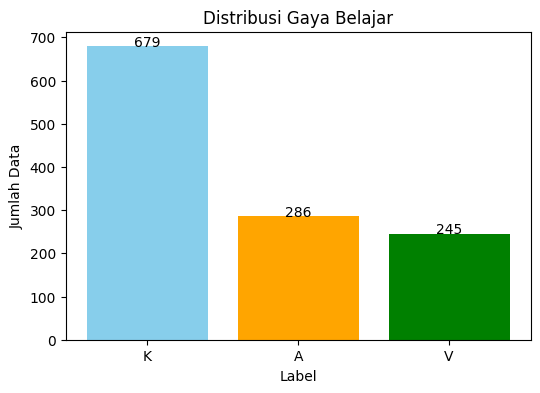

In [11]:
# Hitung jumlah data per label
label_counts = df['learner'].value_counts()

# --- Diagram Batang dengan jumlah data ---
plt.figure(figsize=(6,4))
bars = plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'orange', 'green'])
plt.title('Distribusi Gaya Belajar')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')

# Tambahkan jumlah di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', fontsize=10)

plt.show()

In [20]:
from collections import Counter

# Menampilkan informasi mapping untuk Bab 4
print("Mapping Label:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Distribusi Awal (Sebelum SMOTE):", Counter(y_encoded))

Mapping Label: {'A': np.int64(0), 'K': np.int64(1), 'V': np.int64(2)}
Distribusi Awal (Sebelum SMOTE): Counter({np.int64(1): 679, np.int64(0): 286, np.int64(2): 245})


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

print("Distribusi Akhir (Sesudah SMOTE):", Counter(y_resampled))

Distribusi Akhir (Sesudah SMOTE): Counter({np.int64(1): 679, np.int64(0): 679, np.int64(2): 679})


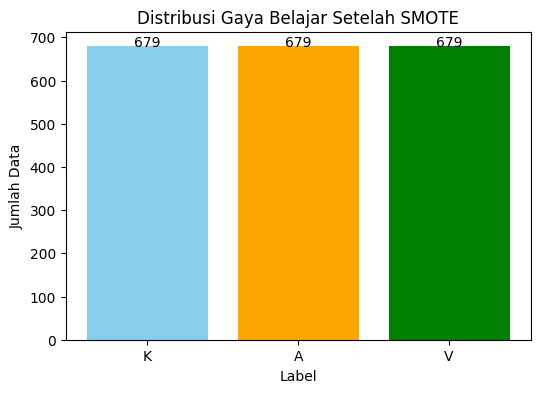

In [23]:
import matplotlib.pyplot as plt
from collections import Counter

# Hitung jumlah data per label setelah SMOTE
resampled_label_counts = Counter(y_resampled)

# Pisahkan label dan jumlahnya
labels = list(resampled_label_counts.keys())
counts = list(resampled_label_counts.values())

# Konversi label numerik kembali ke nama aslinya jika ada mapping
# Menggunakan `le.inverse_transform` untuk mendapatkan kembali label aslinya
display_labels = le.inverse_transform(labels)

# --- Diagram Batang dengan jumlah data setelah SMOTE ---
plt.figure(figsize=(6,4))
bars = plt.bar(display_labels, counts, color=['skyblue', 'orange', 'green'])
plt.title('Distribusi Gaya Belajar Setelah SMOTE')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')

# Tambahkan jumlah di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', fontsize=10)

plt.show()

# data splitting

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.1, random_state=42, stratify=y_resampled
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

from collections import Counter
print("Distribusi kelas y_train:", Counter(y_train))
print("Distribusi kelas y_test:", Counter(y_test))

Ukuran X_train: (1833, 15)
Ukuran X_test: (204, 15)
Ukuran y_train: (1833,)
Ukuran y_test: (204,)
Distribusi kelas y_train: Counter({np.int64(1): 611, np.int64(2): 611, np.int64(0): 611})
Distribusi kelas y_test: Counter({np.int64(2): 68, np.int64(1): 68, np.int64(0): 68})


# modeling

In [79]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import numpy as np

# Model XGBoost
model = XGBClassifier(
    n_estimators=600,
    random_state=0,
    max_depth=3,
    min_child_weight=0,
    gamma=0.1,
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    learning_rate=0.1
)

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy_train = model.score(X_train, y_train)
accuracy_test = model.score(X_test, y_test)

print('Akurasi data training:', np.round(accuracy_train * 100, 2))
print('Akurasi data testing:', np.round(accuracy_test * 100, 2))

Akurasi data training: 99.84
Akurasi data testing: 95.59


# model evaluation


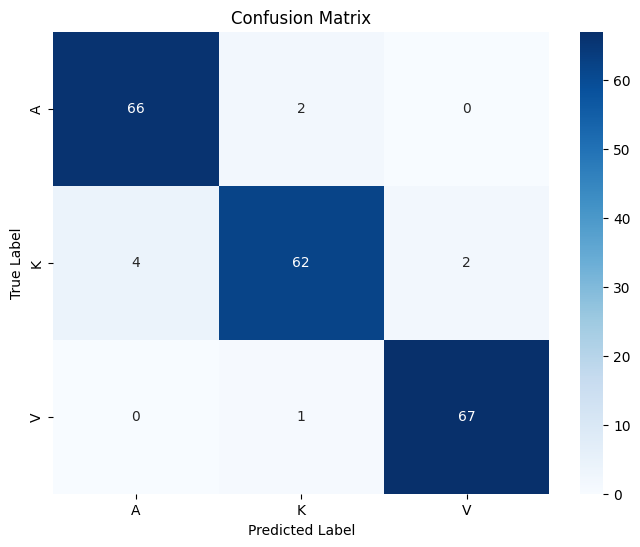


Classification Report:
              precision    recall  f1-score   support

           A       0.94      0.97      0.96        68
           K       0.95      0.91      0.93        68
           V       0.97      0.99      0.98        68

    accuracy                           0.96       204
   macro avg       0.96      0.96      0.96       204
weighted avg       0.96      0.96      0.96       204



In [78]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels from LabelEncoder for better visualization
class_names = le.inverse_transform(np.unique(y_test)) # Get original class names

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

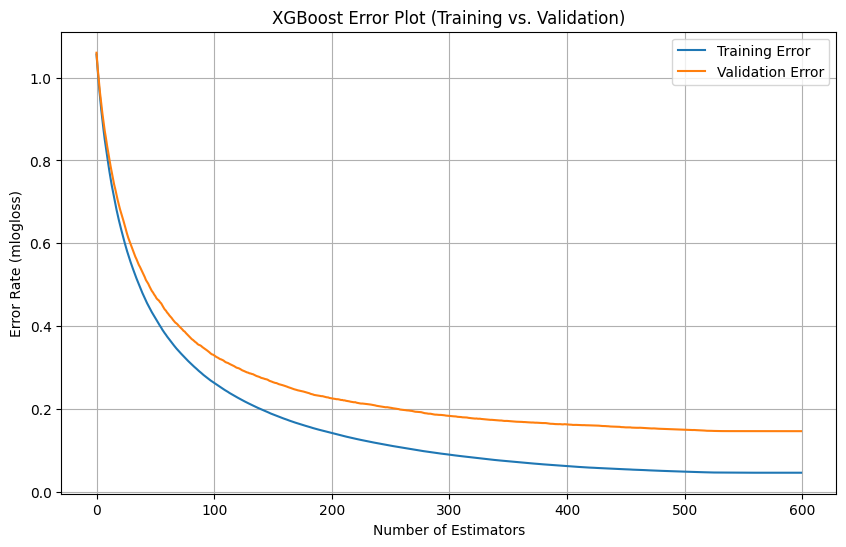

In [80]:
import matplotlib.pyplot as plt

results = model.evals_result()
epochs = len(results['validation_0']['mlogloss']) # Changed 'merror' to 'mlogloss'
x = range(0, epochs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, results['validation_0']['mlogloss'], label='Training Error') # Changed 'merror' to 'mlogloss'
ax.plot(x, results['validation_1']['mlogloss'], label='Validation Error') # Changed 'merror' to 'mlogloss'
ax.legend()
plt.ylabel('Error Rate (mlogloss)') # Updated label
plt.xlabel('Number of Estimators')
plt.title('XGBoost Error Plot (Training vs. Validation)')
plt.grid(True)
plt.show()